## Zero-Shot Image Classification

In [1]:
import fiftyone as fo
import fiftyone.zoo as foz
import fiftyone.brain as fob
from fiftyone import ViewField as F

In [2]:
# fo.delete_dataset("CLIP-Comparison")
fo.list_datasets()

['2025.06.19.17.22.46',
 '2025.06.19.17.57.43',
 'CLIP-Comparison',
 'birds-test-dataset',
 'birds-train-data',
 'coco-2017-test',
 'coco-2017-train',
 'coco-2017-validation',
 'demo0424',
 'evaluate-detections-tutorial',
 'kolp_dataset',
 'ls-annotation-example',
 'migration_test',
 'mnist-test',
 'open-images-v6',
 'quickstart',
 'quickstart-geo',
 'quickstart-video',
 'test_raw_imgs']

In [10]:
dataset = foz.load_zoo_dataset(
    'open-images-v6',
    max_samples=1000,
    split='train',
    classes=['Car'],
    label_types=['classifications'],
    shuffle=True,
    seed=19,
    persistent=True
)
dataset.name = "CLIP-Comparison"

Found 485 images, downloading the remaining 515
 100% |███████████████████| 515/515 [28.8s elapsed, 0s remaining, 10.8 files/s]      
Dataset info written to '/Users/bhc/fiftyone/open-images-v6/info.json'
Loading 'open-images-v6' split 'train'
 100% |███████████████| 1000/1000 [886.1ms elapsed, 0s remaining, 1.1K samples/s]      
Dataset 'open-images-v6-train-1000' created



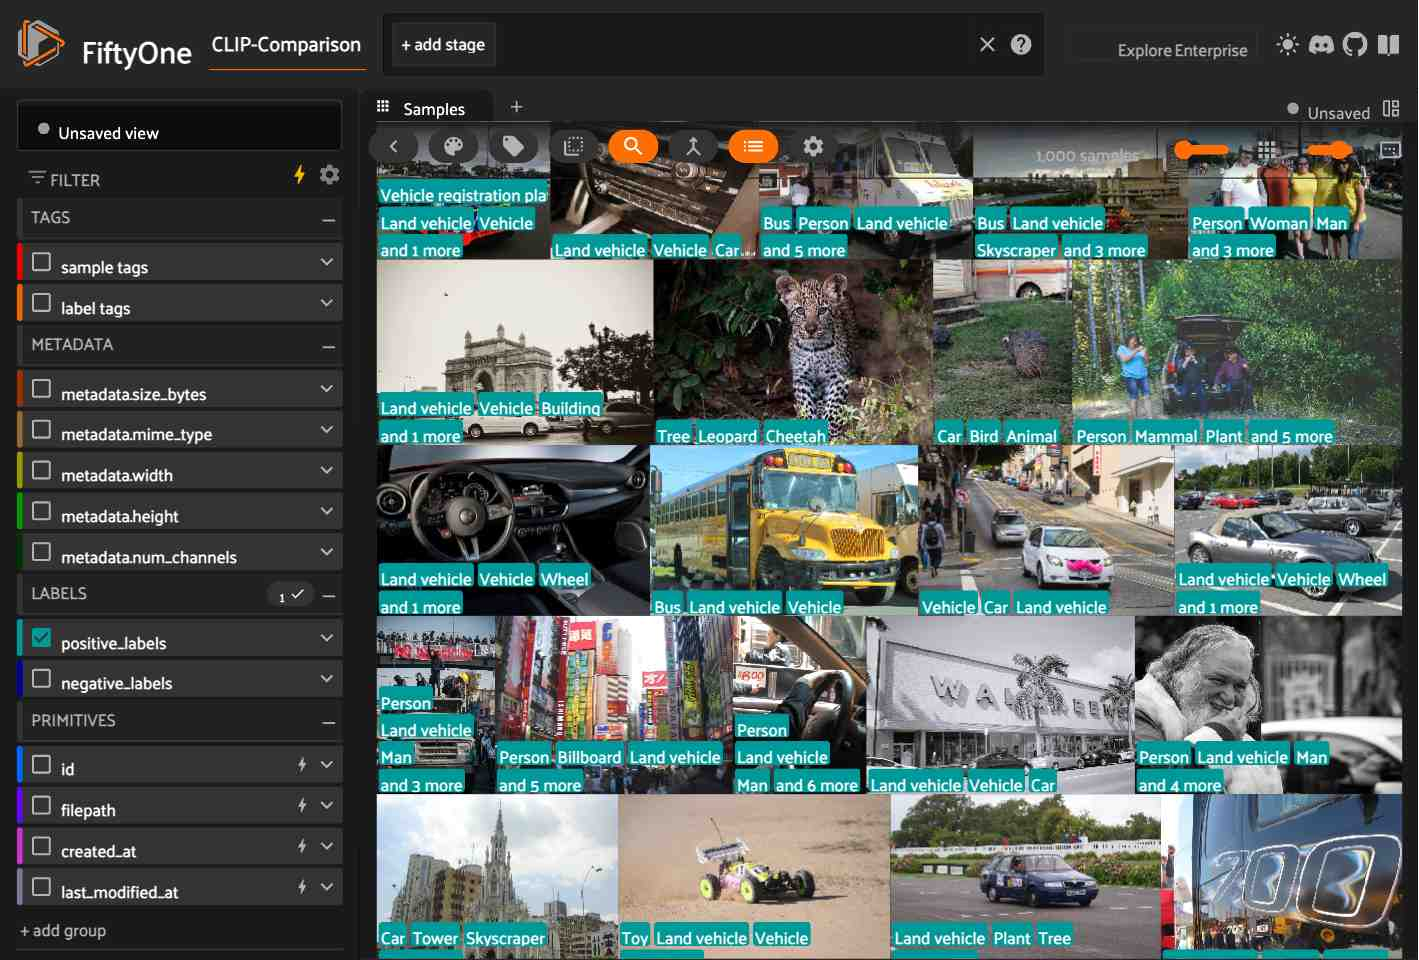

In [11]:
session = fo.launch_app(dataset)

In [12]:
classes = dataset.get_classes("v6")
print(len(classes))

601


In [13]:
clip = foz.load_zoo_model(
    "clip-vit-base32-torch",
    classes=classes,
)
dataset.apply_model(clip, label_field="clip")

 100% |███████████████| 1000/1000 [38.2s elapsed, 0s remaining, 27.8 samples/s]      


In [14]:
field = dataset.get_field("clip")
field.description = "OpenAI CLIP predictions"
field.info = {"clip_model": "CLIP-ViT-B-32"}
field.save()

In [15]:
session = fo.launch_app(dataset, auto=False)

Session launched. Run `session.show()` to open the App in a cell output.



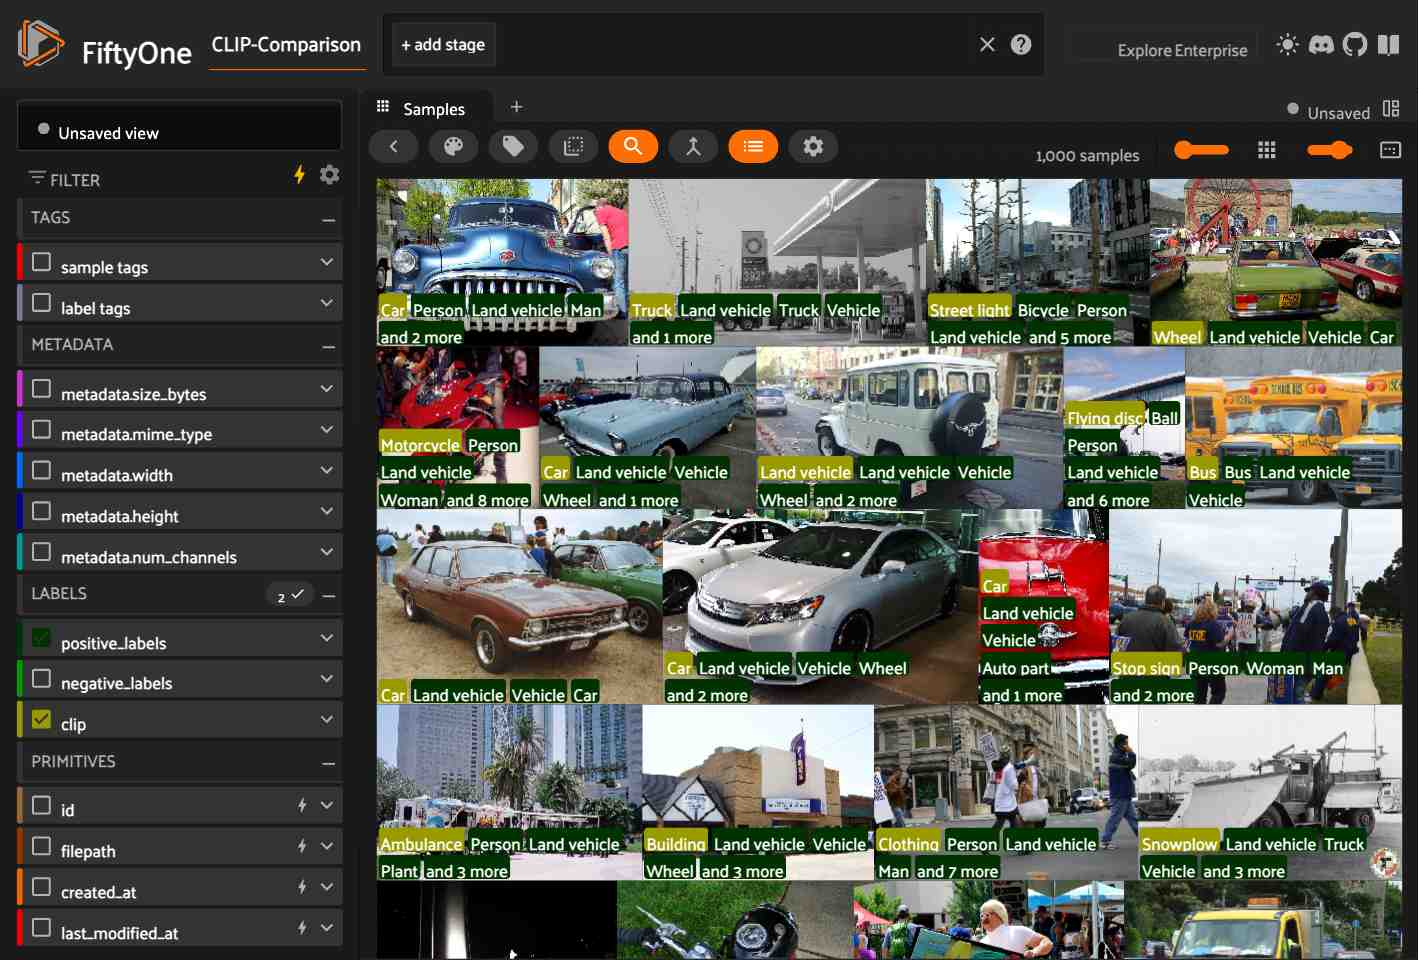

In [16]:
session.show()

### test multiple clip models

In [17]:
dataset.delete_sample_field('clip')
dataset

Name:        CLIP-Comparison
Media type:  image
Num samples: 1000
Persistent:  True
Tags:        []
Sample fields:
    id:               fiftyone.core.fields.ObjectIdField
    filepath:         fiftyone.core.fields.StringField
    tags:             fiftyone.core.fields.ListField(fiftyone.core.fields.StringField)
    metadata:         fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.metadata.ImageMetadata)
    created_at:       fiftyone.core.fields.DateTimeField
    last_modified_at: fiftyone.core.fields.DateTimeField
    positive_labels:  fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Classifications)
    negative_labels:  fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Classifications)

In [18]:
open_clip_args = {
    "clipa": {
        "clip_model": 'hf-hub:UCSC-VLAA/ViT-L-14-CLIPA-datacomp1B',
        "pretrained": '',
        },
    "dfn": {
        "clip_model": 'ViT-B-16',
        "pretrained": 'dfn2b',
        },
    "eva02_clip": {
        "clip_model": 'EVA02-B-16',
        "pretrained": 'merged2b_s8b_b131k',
        },
    "metaclip": {
        "clip_model": 'ViT-B-32-quickgelu',
        "pretrained": 'metaclip_400m',
        },
    "siglip": {
        "clip_model": 'hf-hub:timm/ViT-B-16-SigLIP',
        "pretrained": '',
        },
    }

In [19]:
for name, args in open_clip_args.items():
    clip_model = args["clip_model"]
    pretrained = args["pretrained"]
    model = foz.load_zoo_model(
        "open-clip-torch",
        clip_model=clip_model,
        pretrained=pretrained,
        classes=classes,
    )

    dataset.apply_model(model, label_field=name)

 100% |███████████████| 1000/1000 [3.7m elapsed, 0s remaining, 4.6 samples/s]      


INFO:eta.core.utils: 100% |███████████████| 1000/1000 [3.7m elapsed, 0s remaining, 4.6 samples/s]      


open_clip_pytorch_model.bin:   0%|          | 0.00/599M [00:00<?, ?B/s]

/Users/bhc/opt/anaconda3/envs/datadrift/lib/python3.12/site-packages/open_clip/factory.py:388: UserWarning: These pretrained weights were trained with QuickGELU activation but the model config does not have that enabled. Consider using a model config with a "-quickgelu" suffix or enable with a flag.
  warnings.warn(


 100% |███████████████| 1000/1000 [1.1m elapsed, 0s remaining, 15.3 samples/s]      


...

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

 100% |███████████████| 1000/1000 [1.2m elapsed, 0s remaining, 15.6 samples/s]      


INFO:eta.core.utils: 100% |███████████████| 1000/1000 [1.2m elapsed, 0s remaining, 15.6 samples/s]      


### add transformers predictions

In [4]:
dataset = fo.load_dataset("CLIP-Comparison")
dataset

Name:        CLIP-Comparison
Media type:  image
Num samples: 1000
Persistent:  True
Tags:        []
Sample fields:
    id:               fiftyone.core.fields.ObjectIdField
    filepath:         fiftyone.core.fields.StringField
    tags:             fiftyone.core.fields.ListField(fiftyone.core.fields.StringField)
    metadata:         fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.metadata.ImageMetadata)
    created_at:       fiftyone.core.fields.DateTimeField
    last_modified_at: fiftyone.core.fields.DateTimeField
    positive_labels:  fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Classifications)
    negative_labels:  fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Classifications)
    clipa:            fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Classification)
    dfn:              fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Classification)
    eva02_clip:       fiftyone.core.fields.EmbeddedDocument

In [7]:
classes = dataset.get_classes("v6")
print(len(classes))

601


In [8]:
transformer_model_repo_ids = {
    "altclip": "BAAI/AltCLIP",
    "align": "kakaobrain/align-base"
}

In [9]:
for name, repo_id in transformer_model_repo_ids.items():
    model = foz.load_zoo_model(
        "zero-shot-classification-transformer-torch",
        name_or_path=repo_id,
        classes=classes,
    )

    dataset.apply_model(model, label_field=name)

preprocessor_config.json:   0%|          | 0.00/559 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


tokenizer_config.json:   0%|          | 0.00/513 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

   0% ||--------------|    0/1000 [11.5ms elapsed, ? remaining, ? samples/s] 

/Users/bhc/opt/anaconda3/envs/datadrift/lib/python3.12/site-packages/transformers/tokenization_utils_base.py:2714: UserWarning: `max_length` is ignored when `padding`=`True` and there is no truncation strategy. To pad to max length, use `padding='max_length'`.
  warnings.warn(


 100% |███████████████| 1000/1000 [42.6m elapsed, 0s remaining, 0.4 samples/s]    


In [10]:
session = fo.launch_app(dataset)

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)



Could not connect session, trying again in 10 seconds


Could not connect session, trying again in 10 seconds



## 3D Point Clouds with Point-E

### package install

In [ ]:
# !git clone https://github.com/openai/point-e.git
# !cd point-e
# !pip install -e .
# !pip install open3d

In [2]:
import numpy as np
import open3d as o3d
import random
import torch
from tqdm.auto import tqdm
import uuid

import fiftyone as fo
import fiftyone.brain as fob
import fiftyone.zoo as foz
import fiftyone.utils.utils3d as fou3d
from fiftyone import ViewField as F

from point_e.diffusion.configs import DIFFUSION_CONFIGS, diffusion_from_config
from point_e.diffusion.sampler import PointCloudSampler
from point_e.models.download import load_checkpoint
from point_e.models.configs import MODEL_CONFIGS, model_from_config
from point_e.util.plotting import plot_point_cloud

In [8]:
# device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
device = torch.device('cpu')

In [9]:
base_name = 'base40M-textvec'
base_model = model_from_config(MODEL_CONFIGS[base_name], device)
base_model.eval();
base_model.load_state_dict(load_checkpoint(base_name, device));
base_diffusion = diffusion_from_config(DIFFUSION_CONFIGS[base_name])

In [10]:
upsampler_model = model_from_config(MODEL_CONFIGS['upsample'], device)
upsampler_model.eval()
upsampler_diffusion = diffusion_from_config(DIFFUSION_CONFIGS['upsample'])
upsampler_model.load_state_dict(load_checkpoint('upsample', device))

<All keys matched successfully>

In [11]:
sampler = PointCloudSampler(
    device=device,
    models=[base_model, upsampler_model],
    diffusions=[base_diffusion, upsampler_diffusion],
    num_points=[1024, 4096 - 1024],
    aux_channels=['R', 'G', 'B'],
    guidance_scale=[3.0, 0.0],
    model_kwargs_key_filter=('texts', ''), # Do not condition the upsampler at all
)

In [12]:
# Set a prompt to condition on.
prompt = 'red and silver headphones'

# Produce a sample from the model.
samples = None
for x in tqdm(sampler.sample_batch_progressive(batch_size=1, model_kwargs=dict(texts=[prompt]))):
    samples = x

0it [00:00, ?it/s]

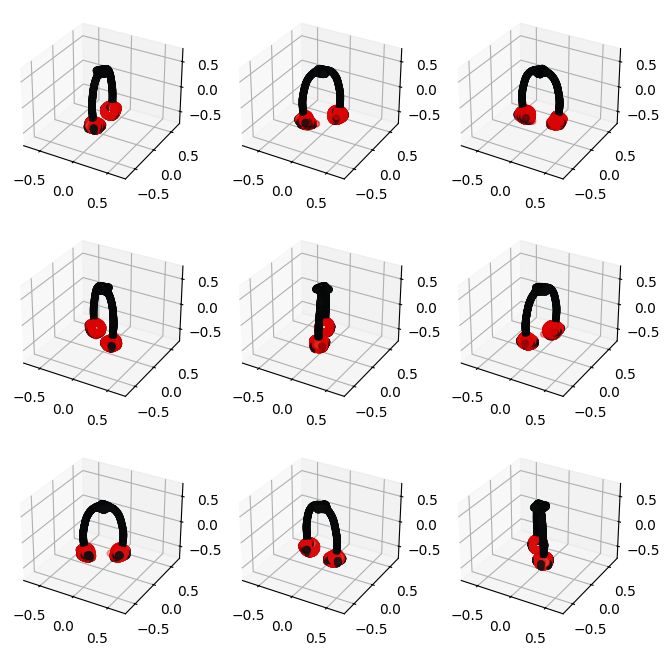

In [13]:
pc = sampler.output_to_point_clouds(samples)[0]
fig = plot_point_cloud(pc, grid_size=3, fixed_bounds=((-0.75, -0.75, -0.75),(0.75, 0.75, 0.75)))

In [14]:
print(pc)

PointCloud(coords=array([[ 0.03039772,  0.22188805, -0.49951014],
       [-0.01532966,  0.1469377 ,  0.44019833],
       [ 0.08375158,  0.1736681 , -0.40579405],
       ...,
       [ 0.0277766 ,  0.2902064 , -0.35261312],
       [-0.0802759 , -0.20925571, -0.43048972],
       [-0.03867117, -0.14162225, -0.47892034]], dtype=float32), channels={'R': array([0.8627451 , 0.02745098, 0.64705884, ..., 0.85882354, 0.8627451 ,
       0.84313726], dtype=float32), 'G': array([0.04313726, 0.03137255, 0.03529412, ..., 0.00784314, 0.03921569,
       0.01960784], dtype=float32), 'B': array([0.02745098, 0.03137255, 0.03137255, ..., 0.00784314, 0.03921569,
       0.01960784], dtype=float32)})


In [15]:
print(pc.coords.shape)

(4096, 3)


In [16]:
print(pc.channels.keys())

dict_keys(['R', 'G', 'B'])


In [12]:
def generate_pcd_from_text(prompt):
    samples = None
    for x in sampler.sample_batch_progressive(batch_size=1, model_kwargs=dict(texts=[prompt])):
        samples = x
    pointe_pcd = sampler.output_to_point_clouds(samples)[0]

    channels = pointe_pcd.channels
    r, g, b = channels["R"], channels["G"], channels["B"]
    colors = np.vstack((r, g, b)).T
    points = pointe_pcd.coords

    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(points)
    pcd.colors = o3d.utility.Vector3dVector(colors)
    return pcd

In [18]:
headphone_pcd = generate_pcd_from_text('red and silver headphones')
headphone_file = "headphone.pcd"
o3d.io.write_point_cloud(headphone_file, headphone_pcd)

True

In [ ]:
headphone_dataset = fo.Dataset(name = "headphone_dataset")
headphone_dataset.add_sample(
    fo.Sample(filepath=headphone_file)
)

In [17]:
headphone_dataset = fo.load_dataset(name = "headphone_dataset")

session = fo.launch_app(headphone_dataset)

In [ ]:
session.close()

: 

### vehicle dataset

In [3]:
import numpy as np
import open3d as o3d
import random
import torch
from tqdm.auto import tqdm
import uuid

import fiftyone as fo
import fiftyone.brain as fob
import fiftyone.zoo as foz
import fiftyone.utils.utils3d as fou3d
from fiftyone import ViewField as F

from point_e.diffusion.configs import DIFFUSION_CONFIGS, diffusion_from_config
from point_e.diffusion.sampler import PointCloudSampler
from point_e.models.download import load_checkpoint
from point_e.models.configs import MODEL_CONFIGS, model_from_config
from point_e.util.plotting import plot_point_cloud

In [4]:
VEHICLE_TYPES = ["car", "bus", "bike", "motorcycle"]
VEHICLE_COLORS = ["red", "blue", "green", "yellow", "white"]

In [5]:
device = torch.device('cpu')

base_name = 'base40M-textvec'
base_model = model_from_config(MODEL_CONFIGS[base_name], device)
base_model.eval();
base_model.load_state_dict(load_checkpoint(base_name, device));
base_diffusion = diffusion_from_config(DIFFUSION_CONFIGS[base_name])

upsampler_model = model_from_config(MODEL_CONFIGS['upsample'], device)
upsampler_model.eval()
upsampler_diffusion = diffusion_from_config(DIFFUSION_CONFIGS['upsample'])
upsampler_model.load_state_dict(load_checkpoint('upsample', device))

sampler = PointCloudSampler(
    device=device,
    models=[base_model, upsampler_model],
    diffusions=[base_diffusion, upsampler_diffusion],
    num_points=[1024, 4096 - 1024],
    aux_channels=['R', 'G', 'B'],
    guidance_scale=[3.0, 0.0],
    model_kwargs_key_filter=('texts', ''), # Do not condition the upsampler at all
)

In [9]:
def generate_pcd_from_text(prompt):
    samples = None
    for x in sampler.sample_batch_progressive(batch_size=1, model_kwargs=dict(texts=[prompt])):
        samples = x
    pointe_pcd = sampler.output_to_point_clouds(samples)[0]

    channels = pointe_pcd.channels
    r, g, b = channels["R"], channels["G"], channels["B"]
    colors = np.vstack((r, g, b)).T
    points = pointe_pcd.coords

    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(points)
    pcd.colors = o3d.utility.Vector3dVector(colors)
    return pcd

In [10]:
def generate_filename():
    rand_str = str(uuid.uuid1()).split('-')[0]
    return "pointe_vehicles/" + rand_str + ".pcd"

In [14]:
def generate_pointe_vehicle_dataset(dataset_name="point-e-vehicles", num_samples=5):
    samples = []
    for i in tqdm(range(num_samples)):
        vehicle_type = random.choice(VEHICLE_TYPES)
        cols = random.choices(VEHICLE_COLORS, k=2)
        prompt = f"a {cols[0]} {vehicle_type} with {cols[1]} wheels"
        pcd = generate_pcd_from_text(prompt)
        ofile = generate_filename()
        o3d.io.write_point_cloud(ofile, pcd)

        sample = fo.Sample(
            filepath = ofile,
            vehicle_type = fo.Classification(label = vehicle_type)
        )
        samples.append(sample)

    dataset = fo.Dataset(dataset_name)
    dataset.add_samples(samples)
    return dataset

In [15]:
vehicle_dataset = generate_pointe_vehicle_dataset(
    dataset_name = "point-e-vehicles",
    num_samples = 5
)

  0%|          | 0/5 [00:00<?, ?it/s]

 100% |█████████████████████| 5/5 [16.9ms elapsed, 0s remaining, 296.3 samples/s]    


In [16]:
vehicle_dataset.persistent = True

In [22]:
size = (-1, 608)
## height of images should be 608 pixels
## - with aspect ratio preserved

fou3d.compute_orthographic_projection_images(
    vehicle_dataset,
    size,
    "/Users/bhc/dev/drift_v1/datadrift_app_engine/notebooks/pointe_vehicles/vehicle_side_view_images",
    shading_mode="height",
    projection_normal = (0, -1, 0)
)

 100% |█████████████████████| 5/5 [51.9ms elapsed, 0s remaining, 96.3 samples/s] 



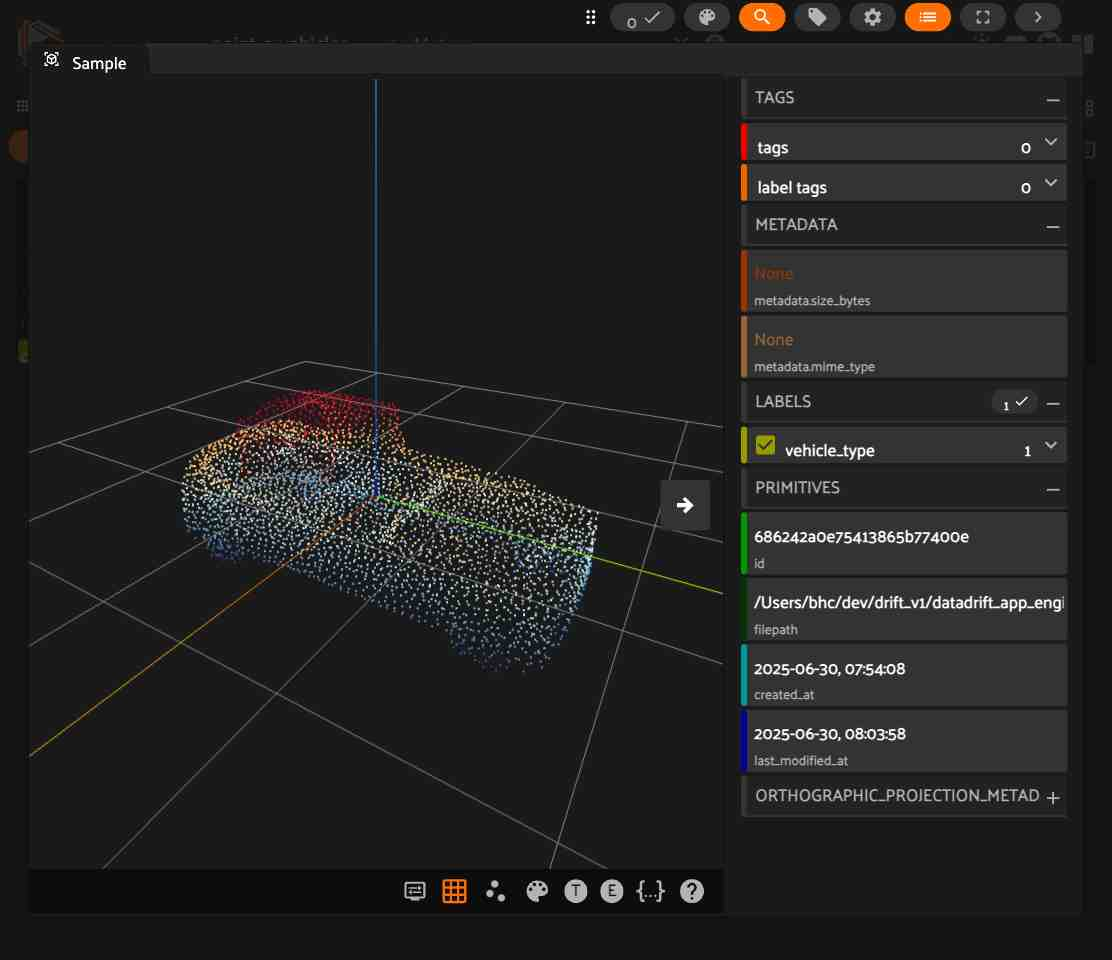

In [23]:
session = fo.launch_app(vehicle_dataset)

## Monocular Depth Estimation

### donwload dataset

In [24]:
!curl -o sunrgbd.zip https://rgbd.cs.princeton.edu/data/SUNRGBD.zip

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 6566M  100 6566M    0     0  7872k      0  0:14:14  0:14:14 --:--:-- 3642k     0  0:15:15  0:00:08  0:15:07 11.3M    0  0:12:14  0:00:27  0:11:47 8553k  0  9155k      0  0:12:14  0:00:29  0:11:45 9092k   0  0:13:30  0:00:55  0:12:35 2550k4k      0  0:13:51  0:00:57  0:12:54 2446k:01:27  0:18:26  249k00k      0  0:22:52  0:01:42  0:21:10  587k946k      0  0:28:24  0:02:19  0:26:05 2251k26:12  0:02:35  0:23:37 4276k    0  4267k      0  0:26:15  0:02:56  0:23:19 5553k26:46  0:03:14  0:23:32 3319k9k      0  0:26:25  0:03:28  0:22:57 6154k0     0  4366k      0  0:25:39  0:03:33  0:22:06 9647k  4579k      0  0:24:28  0:03:39  0:20:49 11.8M:19:16  0:04:23  0:14:53 11.1M0:04:30  0:14:18 11.0M 0  6204k      0  0:18:03  0:04:42  0:13:21 11.8M43k      0  0:17:07  0:05:00  0:12:07 11.8M      0  0:16:49  0:05:06  0:11:43 12.2M05:24  0:10:3

In [ ]:
!unzip sunrgbd.zip --verbose False

In [38]:
from glob import glob
import numpy as np
from PIL import Image
import torch

import fiftyone as fo
import fiftyone.zoo as foz
import fiftyone.brain as fob
from fiftyone import ViewField as F

In [39]:
fo.delete_dataset("SUNRGBD-20")

In [40]:
dataset = fo.Dataset(name="SUNRGBD-20", persistent=True)

In [41]:
scene_dirs = glob("SUNRGBD/k*/*/*")[:20]

In [42]:
samples = []
for scene_dir in scene_dirs:
    ## Get image file path from scene directory
    image_path = glob(f"{scene_dir}/image/*")[0]

    ## Get depth map file path from scene directory
    depth_path = glob(f"{scene_dir}/depth_bfx/*")[0]

    depth_map = np.array(Image.open(depth_path))
    depth_map = (depth_map * 255 / np.max(depth_map)).astype("uint8")
    sample = fo.Sample(
        filepath=image_path,
        depth=fo.Heatmap(map=depth_map),
    )

    samples.append(sample)

dataset.add_samples(samples);

 100% |███████████████████| 20/20 [195.4ms elapsed, 0s remaining, 102.9 samples/s]    



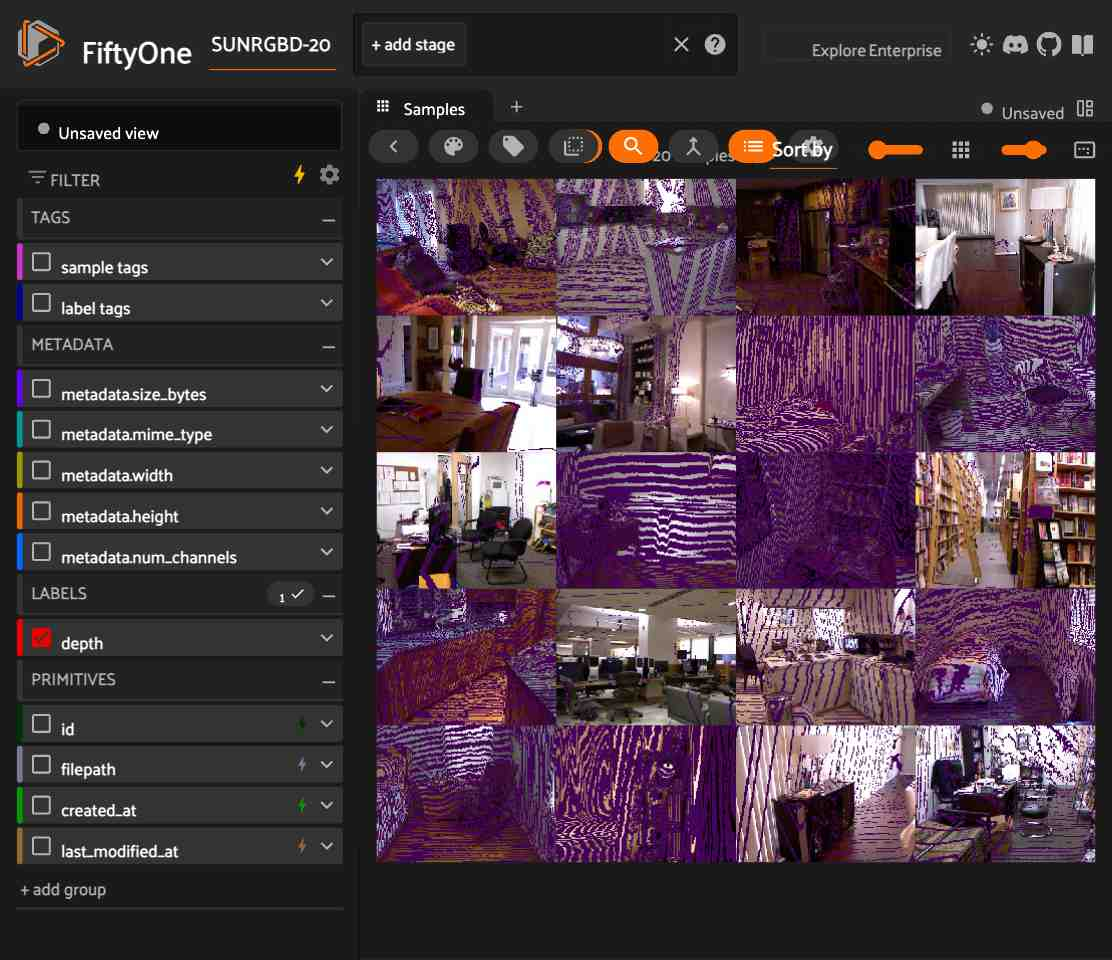

In [43]:
session = fo.launch_app(dataset)

In [44]:
from transformers import AutoImageProcessor, AutoModelForDepthEstimation

image_processor = AutoImageProcessor.from_pretrained("Intel/dpt-hybrid-midas")
dpt_model = AutoModelForDepthEstimation.from_pretrained("Intel/dpt-hybrid-midas")

## you can also us a different model:
# image_processor = AutoImageProcessor.from_pretrained("Intel/dpt-large")
# dpt_model = AutoModelForDepthEstimation.from_pretrained("Intel/dpt-large")

def apply_dpt_model(sample, model, label_field):
    image = Image.open(sample.filepath)
    inputs = image_processor(images=image, return_tensors="pt")

    with torch.no_grad():
        outputs = model(**inputs)
        predicted_depth = outputs.predicted_depth

    prediction = torch.nn.functional.interpolate(
        predicted_depth.unsqueeze(1),
        size=image.size[::-1],
        mode="bicubic",
        align_corners=False,
    )

    output = prediction.squeeze().cpu().numpy()
    ## flip b/c MiDaS returns inverse depth
    formatted = (255 - output * 255 / np.max(output)).astype("uint8")

    sample[label_field] = fo.Heatmap(map=formatted)
    sample.save()

preprocessor_config.json:   0%|          | 0.00/382 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/490M [00:00<?, ?B/s]

In [45]:
for sample in dataset.iter_samples(autosave=True, progress=True):
    apply_dpt_model(sample, dpt_model, "dpt")

   5% |/------------------|  1/20 [785.2ms elapsed, 14.9s remaining, 1.3 samples/s] 

model.safetensors:   0%|          | 0.00/490M [00:00<?, ?B/s]

 100% |███████████████████| 20/20 [10.9s elapsed, 0s remaining, 1.9 samples/s]      


In [46]:
session = fo.launch_app(dataset)